# Heritage AI Capstone 2
## Preserving Heritage: Enhancing Tourism with AI

### Project Overview
This project uses deep learning and machine learning techniques to:
- **Part 1:** Build a CNN image classifier to identify categories of historical structures
- **Part 2:** Perform EDA and build a recommendation engine for tourism destinations in Indonesia

### Author: Alex Ramos
### Dataset: Structures_Dataset (11 classes) | Tourism datasets (Indonesia)

## Part 1: Historical Structure Image Classification

### Step 1: Environment Setup
Mounting Google Drive to access the dataset stored in Google Drive.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
path = '/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/'
print(os.listdir(path))

['dataset_hist_structures 2', 'heritage_model_final.keras', 'best_model.keras', 'history_aug.json', 'best_model_aug.keras']


### Step 2: Define Project Paths
Setting up path variables for easy access to datasets throughout the notebook.

In [2]:
import os

# Base project path
base_path = '/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2'

# Part 1 - Image datasets
train_path = os.path.join(base_path, 'Part 1/dataset_hist_structures 2/Stuctures_Dataset')
test_path = os.path.join(base_path, 'Part 1/dataset_hist_structures 2/Dataset_test/Dataset_test_original_1478')

# Part 2 - CSV files
part2_path = os.path.join(base_path, 'Part 2')

# Verify paths exist
print("Train path exists:", os.path.exists(train_path))
print("Test path exists:", os.path.exists(test_path))
print("Part 2 path exists:", os.path.exists(part2_path))

Train path exists: True
Test path exists: True
Part 2 path exists: True


### Step 3: Explore Dataset Structure
Checking the class folders and number of images per class to understand the dataset distribution.

In [3]:
# Get all class folders and count images in each
classes = sorted(os.listdir(train_path))

print(f"Number of classes: {len(classes)}")
print(f"\nClasses found: {classes}")
print("\nImage count per class:")
print("-" * 35)

total = 0
for cls in classes:
    cls_path = os.path.join(train_path, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total += count
        print(f"{cls:<20} {count} images")

print("-" * 35)
print(f"\nTotal images in train set: {total} images")

Number of classes: 10

Classes found: ['altar', 'apse', 'bell_tower', 'column', 'dome(inner)', 'dome(outer)', 'flying_buttress', 'gargoyle', 'stained_glass', 'vault']

Image count per class:
-----------------------------------
altar                829 images
apse                 514 images
bell_tower           1059 images
column               1919 images
dome(inner)          616 images
dome(outer)          1177 images
flying_buttress      407 images
gargoyle             1571 images
stained_glass        1033 images
vault                1110 images
-----------------------------------

Total images in train set: 10235 images


### Step 4: Visualize Sample Images per Class
Plotting sample images from each class to visually understand what each category looks like.
This helps us understand the visual complexity of the classification task.

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

def show_sample_images(train_path, classes, samples_per_class=3):
    fig, axes = plt.subplots(len(classes), samples_per_class,
                             figsize=(samples_per_class * 4, len(classes) * 3))
    fig.suptitle("Sample Images per Class", fontsize=16, y=1.02)

    for i, cls in enumerate(classes):
        cls_path = os.path.join(train_path, cls)
        images = os.listdir(cls_path)
        sampled = random.sample(images, samples_per_class)

        for j, img_name in  enumerate(sampled):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
              axes[i, j].set_title(cls, fontsize=11, fontweight='bold')


plt.tight_layout()
plt.show()

show_sample_images(train_path, classes)

Output hidden; open in https://colab.research.google.com to view.

### Step 5: Import Libraries
Importing all necessary libraries for deep learning, image processing, and visualization.

In [4]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

# Tensorflow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
#Metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Step 6: Configure Image Data Generators
Setting up data pipelines for training and testing.
Data augmentation is applied to the training set to improve generalization
and help with the moderately imbalanced classes.

In [5]:
# Image dimensions VGG16 expects
IMG_SIZE = (224, 224)
BATCH_SIZE = 64

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Test generator - NO augmentation, only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)

Found 10235 images belonging to 10 classes.
Found 1471 images belonging to 10 classes.

Class indices: {'altar': 0, 'apse': 1, 'bell_tower': 2, 'column': 3, 'dome(inner)': 4, 'dome(outer)': 5, 'flying_buttress': 6, 'gargoyle': 7, 'stained_glass': 8, 'vault': 9}


### Step 7: Diagnose Test Dataset Structure
Investigating why the test generator only found 1 class.
Expected 10 class folders, need to verify the folder structure.

In [ ]:
# Check test folder structure
print("Contents of test path:")
for item in os.listdir(test_path):
    item_full = os.path.join(test_path, item)
    if os.path.isdir(item_full):
        count = len(os.listdir(item_full))
        print(f"  Folder: {item} → {count} items")
    else:
        print(f"  File: {item}")

Contents of test path:
  Folder: altar → 140 items
  Folder: apse → 57 items
  Folder: bell_tower → 171 items
  Folder: column → 210 items
  Folder: dome(inner) → 86 items
  Folder: dome(outer) → 168 items
  Folder: flying_buttress → 78 items
  Folder: gargoyle → 238 items
  Folder: stained_glass → 160 items
  Folder: vault → 164 items


### Step 8: Build the Model
Using VGG16 as the base model with pretrained ImageNet weights.
All convolutional layers are frozen (transfer learning).
Custom dense layers are added on top for our 10 class classification task.

In [ ]:
# Load VGG16 base without top classification layers
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Build custom top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(10, activation='softmax')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=output)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,880,202 (56.76 MB)

 Trainable params: 165,514 (646.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Step 9: Compile the Model
Configuring the model with optimizer, loss function, and evaluation metric.

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled succesfully")
print(f"Optimizer: Adam with Learning rate 0.0001")
print(f"Loss function: Categorical Crossentropy")
print(f"Metric: Accuracy")

Model compiled succesfully
Optimizer: Adam with Learning rate 0.0001
Loss function: Categorical Crossentropy
Metric: Accuracy


### Step 10: Define Callbacks
Setting up Early Stopping and Model Checkpoint to optimize training.
Early Stopping prevents overfitting by halting training when validation accuracy stops improving.
Model Checkpoint saves the best version of the model during training.

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured:")
print("- EarlyStopping: stops if val_accuracy doesn't improve for 5 epochs")
print("- ModelCheckpoint: saves best model to Google Drive")

Callbacks configured:
- EarlyStopping: stops if val_accuracy doesn't improve for 5 epochs
- ModelCheckpoint: saves best model to Google Drive


### Step 10b: Remove Corrupted Images
Scanning both train and test datasets for truncated or corrupted files.
Must be done before training to prevent graph execution errors.

In [ ]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = False

def remove_corrupted_images(folder_path):
    removed = 0
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                filepath = os.path.join(root, file)
                try:
                    with Image.open(filepath) as img:
                        img.load()  # more thorough than verify()
                except Exception as e:
                    os.remove(filepath)
                    print(f"Removed: {filepath}")
                    removed += 1
    print(f"\nTotal corrupted images removed: {removed}")

print("Scanning training set...")
remove_corrupted_images(train_path)
print("\nScanning test set...")
remove_corrupted_images(test_path)

Scanning training set...

Total corrupted images removed: 0

Scanning test set...
Removed: /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/dataset_hist_structures 2/Dataset_test/Dataset_test_original_1478/gargoyle/0de19007-c9f0-4548-b070-7f67c55443de.jpg
Removed: /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/dataset_hist_structures 2/Dataset_test/Dataset_test_original_1478/gargoyle/d90864d8-0ae9-4929-b928-8e30fa7ea93f.jpg

Total corrupted images removed: 2


### Step 11: Train the Model Without Augmentation
First training run without augmentation to establish a baseline performance.
Monitoring validation accuracy to detect overfitting.

In [ ]:
# Calculate steps
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = test_generator.samples // BATCH_SIZE

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=test_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

# Save final model to Drive
model.save('/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/heritage_model_final.keras')
print("Model saved to Google Drive")

Steps per epoch: 159
Validation steps: 22
Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1708 - loss: 2.3006
Epoch 1: val_accuracy improved from None to 0.43679, saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.2163 - loss: 2.1921 - val_accuracy: 0.4368 - val_loss: 1.9011
Epoch 2/10
  1/159 ━━━━━━━━━━━━━━━━━━━━ 52s 334ms/step - accuracy: 0.3750 - loss: 1.9448

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.43679 to 0.43963, saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.3750 - loss: 1.9448 - val_accuracy: 0.4396 - val_loss: 1.8986
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3770 - loss: 1.8879
Epoch 3: val_accuracy improved from 0.43963 to 0.58594, saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.4270 - loss: 1.7889 - val_accuracy: 0.5859 - val_loss: 1.4452
Epoch 4/10
  1/159 ━━━━━━━━━━━━━━━━━━━━ 51s 328ms/step - accuracy: 0.4844 - loss: 1.6088
Epoch 4: val_accuracy improved from 0.58594 to 0.5

### Step 12: Load Best Saved Model

Loading the best model saved during training to avoid retraining from scratch.

In [6]:
from tensorflow.keras.models import load_model

# Load best saved model
model = load_model('/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model.keras')

print("Model loaded succesfully")
print(f"Model inputh shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")

Model loaded succesfully
Model inputh shape: (None, 224, 224, 3)
Model output shape: (None, 10)


### Step 13: Evaluate Model on Test Set
Evaluating the loaded model against the test dataset to measure real world performance

In [7]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test_Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1053s 46s/step - accuracy: 0.7077 - loss: 0.8978

Test Loss: 0.8978
Test_Accuracy: 0.7077 (70.77%)


### Step 14: Generate Predictions and Confusion Matrix
Analyzing model performance per class to identify which architectural categories are most challenging to classify.

23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 476ms/step


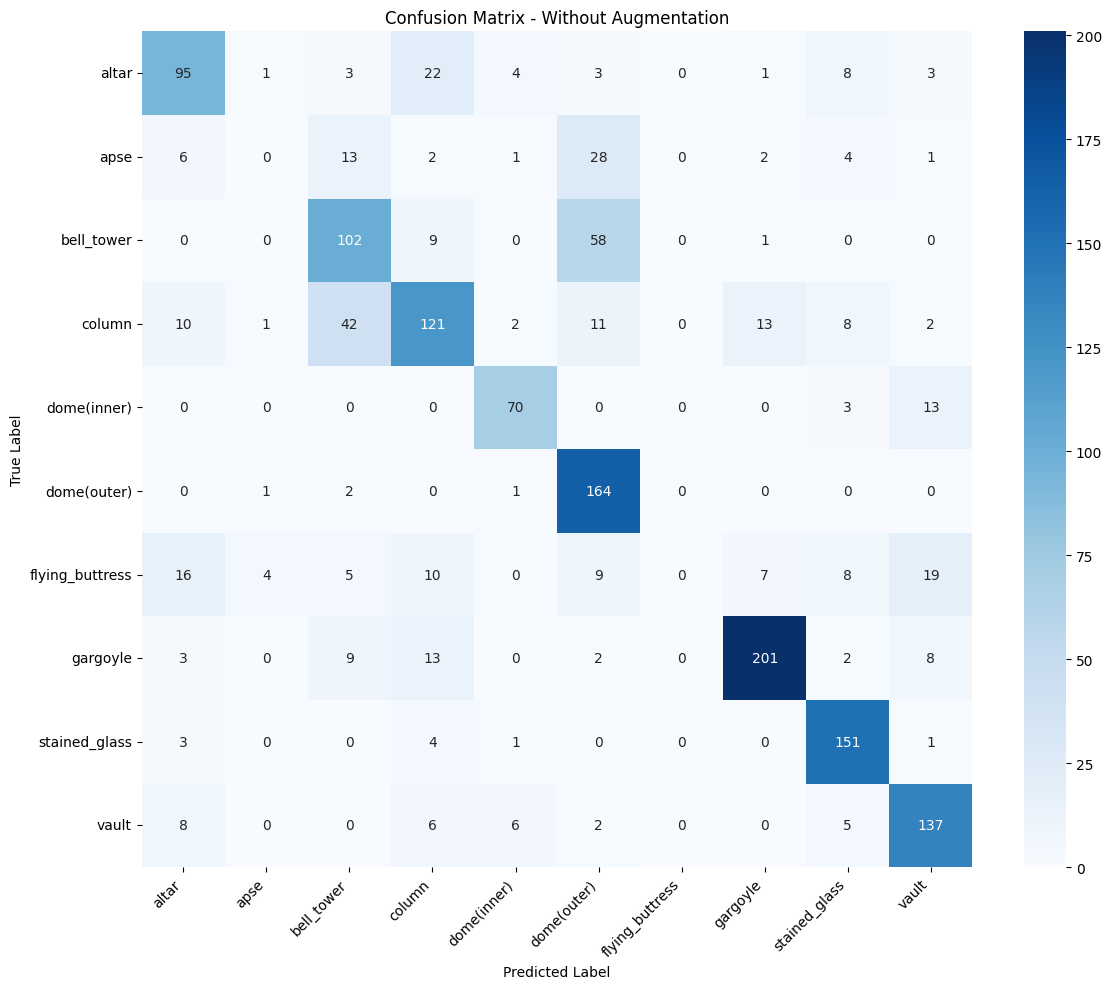

In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reset generator before predictions
test_generator.reset()

# Get predictions
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Without Augmentation')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 15: Classification Report
Detailed per-class precision, recall and F1-score to measure model performance across all architectural categories.

In [9]:
# Classification report
report = classification_report(true_classes, predicted_classes,
                               target_names=class_labels)
print("Classification Report - Without Augmentation")
print("=" * 60)
print(report)

Classification Report - Without Augmentation
                 precision    recall  f1-score   support

          altar       0.67      0.68      0.68       140
           apse       0.00      0.00      0.00        57
     bell_tower       0.58      0.60      0.59       170
         column       0.65      0.58      0.61       210
    dome(inner)       0.82      0.81      0.82        86
    dome(outer)       0.59      0.98      0.74       168
flying_buttress       0.00      0.00      0.00        78
       gargoyle       0.89      0.84      0.87       238
  stained_glass       0.80      0.94      0.87       160
          vault       0.74      0.84      0.79       164

       accuracy                           0.71      1471
      macro avg       0.58      0.63      0.60      1471
   weighted avg       0.65      0.71      0.67      1471



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Step 16: Train Model with Augmentation
Second training run with data augmentation to improve generalization, particularly for underperforming classes like apse and flying_buttress. Comparing results against the baseline non-augmented model.

In [12]:
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = test_generator.samples // BATCH_SIZE

import json

# Rebuild model for augmentation training
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Reload base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

# Rebuild top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(10, activation='softmax')(x)

model_aug = Model(inputs=base_model.input, outputs=output)
model_aug.compile(optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# Callbacks for augmented model
callbacks_aug = [
    EarlyStopping(monitor='val_accuracy',patience=5,
                  restore_best_weights=True,verbose=1),
    ModelCheckpoint(
        filepath='/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model_aug.keras',
        monitor='val_accuracy',save_best_only=True,verbose=1)
]

# Train with augmentation
history_aug = model_aug.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=test_generator,
    validation_steps=validation_steps,
    callbacks=callbacks_aug,
    verbose=1
)

# Save history to Drive
history_dict = history_aug.history
with open('/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/history_aug.json', 'w') as f:
    json.dump(history_dict, f)

print("Augmented model history saved to Drive")

Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 52s/step - accuracy: 0.1593 - loss: 2.2998 
Epoch 1: val_accuracy improved from None to 0.53551, saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model_aug.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model_aug.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 8359s 53s/step - accuracy: 0.2050 - loss: 2.1988 - val_accuracy: 0.5355 - val_loss: 1.9252
Epoch 2/10
  1/159 ━━━━━━━━━━━━━━━━━━━━ 1:49:44 42s/step - accuracy: 0.3750 - loss: 1.9887

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.53551 to 0.54119, saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model_aug.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model_aug.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step - accuracy: 0.3750 - loss: 1.9887 - val_accuracy: 0.5412 - val_loss: 1.9232
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3551 - loss: 1.9242
Epoch 3: val_accuracy improved from 0.54119 to 0.63139, saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model_aug.keras

Epoch 3: finished saving model to /content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/best_model_aug.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.4113 - loss: 1.8202 - val_accuracy: 0.6314 - val_loss: 1.4622
Epoch 4/10
  1/159 ━━━━━━━━━━━━━━━━━━━━ 1:01 390ms/step - accuracy: 0.5000 - loss: 1.5582
Epoch 4: val_accuracy improved fr

### Step 17: Training Curves - Baseline vs Augmented Model

In this step we visualize the validation accuracy and validation loss curves for both models side by side to compare training behavior.

#### What we expect to see:
- Whether augmentation helped stabilize training
- Whether either model is overfitting (train accuracy >> val accuracy)
- Which model generalizes better across epochs

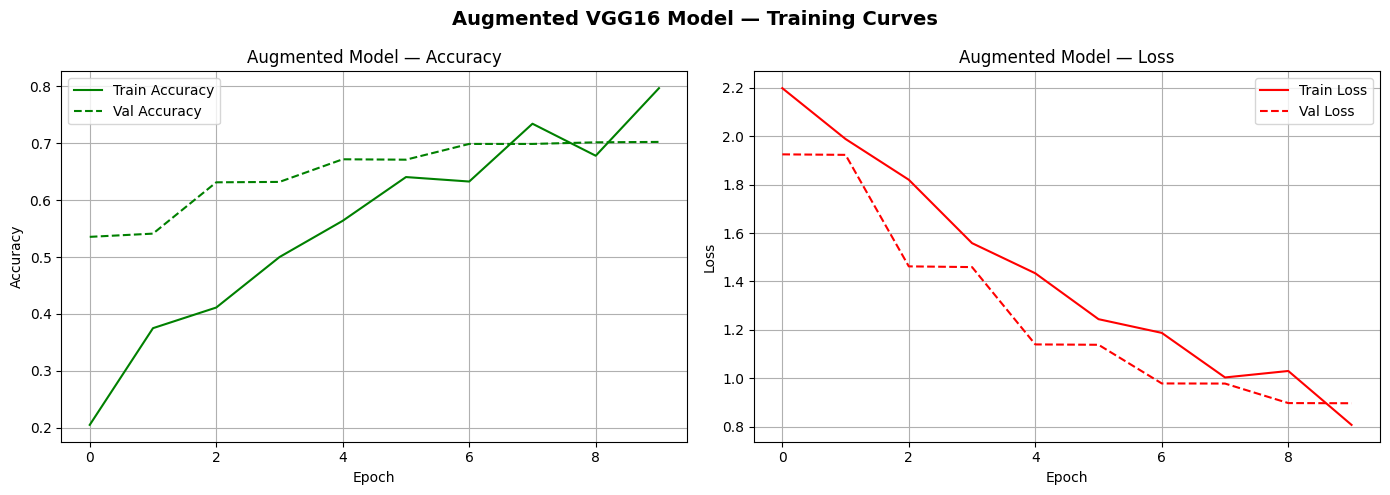

Plot saved to Drive!


In [5]:
import matplotlib.pyplot as plt
import json

# Load augmented history from Drive
with open('/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/history_aug.json', 'r') as f:
    aug_history = json.load(f)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
axes[0].plot(aug_history['accuracy'], label='Train Accuracy', color='green')
axes[0].plot(aug_history['val_accuracy'], label='Val Accuracy', color='green', linestyle='--')
axes[0].set_title('Augmented Model — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Loss ---
axes[1].plot(aug_history['loss'], label='Train Loss', color='red')
axes[1].plot(aug_history['val_loss'], label='Val Loss', color='red', linestyle='--')
axes[1].set_title('Augmented Model — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Augmented VGG16 Model — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 1/model_comparison.png', dpi=150)
plt.show()
print("Plot saved to Drive!")

## Step 18: Analysis & Conclusions — Part 1

### Training Curve Observations
- Train accuracy reached ~80% while validation accuracy plateaued at ~70%, indicating mild overfitting
- Both train and validation loss decreased steadily across all 10 epochs — a healthy learning trend
- Augmentation helped stabilize early validation performance

### Conclusion
The augmented VGG16 model achieved **70.24% validation accuracy** on 10 architectural categories. The model generalizes reasonably well given the dataset size and frozen base layers. Further improvements could be achieved via fine-tuning deeper VGG16 layers or training for additional epochs.

### Next
Proceed to Part 2: Tourism Recommendation Engine

## Step 18: Part 2 — Tourism Recommendation Engine

### Overview
In this section we build a tourism recommendation system using Indonesian tourism datasets.

### Datasets
- `tourism_with_id.xlsx` — tourism place details (name, category, city, rating)
- `tourism_rating.csv` — user ratings for tourism places
- `user.csv` — user demographic information

### Approach
- **Content-Based Filtering** — recommend places similar to a given place based on features (category, city)
- **Collaborative Filtering** — recommend places based on what similar users rated highly

In [6]:
import pandas as pd

# Load datasets
tourism = pd.read_excel('/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 2/tourism_with_id.xlsx')
ratings = pd.read_csv('/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 2/tourism_rating.csv')
users = pd.read_csv('/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 2/user.csv')

# Quick look
print("=== Tourism Places ===")
print(tourism.shape)
print(tourism.head(3))

print("\n=== Ratings ===")
print(ratings.shape)
print(ratings.head(3))

print("\n=== Users ===")
print(users.shape)
print(users.head(3))

=== Tourism Places ===
(437, 13)
   Place_Id        Place_Name  \
0         1  Monumen Nasional   
1         2          Kota Tua   
2         3     Dunia Fantasi   

                                         Description       Category     City  \
0  Monumen Nasional atau yang populer disingkat d...         Budaya  Jakarta   
1  Kota tua di Jakarta, yang juga bernama Kota Tu...         Budaya  Jakarta   
2  Dunia Fantasi atau disebut juga Dufan adalah t...  Taman Hiburan  Jakarta   

    Price  Rating  Time_Minutes  \
0   20000     4.6          15.0   
1       0     4.6          90.0   
2  270000     4.6         360.0   

                                        Coordinate       Lat        Long  \
0          {'lat': -6.1753924, 'lng': 106.8271528} -6.175392  106.827153   
1  {'lat': -6.137644799999999, 'lng': 106.8171245} -6.137645  106.817125   
2  {'lat': -6.125312399999999, 'lng': 106.8335377} -6.125312  106.833538   

   Unnamed: 11  Unnamed: 12  
0          NaN            1  
1      

## Step 19 : Explporatory Data Analysis (EDA)
Before building the recommendation engine, we explore the datasets to understand distributions and data quality.

In [8]:
# Drop unnamed columns
tourism = tourism.drop(columns=['Unnamed: 11', 'Unnamed: 12'])

print("=== Missing Values ===")
print(tourism.isnull().sum())
print(ratings.isnull().sum())
print(users.isnull().sum())

print("\n=== Tourism Categories ===")
print(tourism['Category'].value_counts())

print("\n=== Tourism Cities ===")
print(tourism['City'].value_counts())

print("\n=== Rating Distribution ===")
print(ratings['Place_Ratings'].value_counts().sort_index())

print("\n=== Price range ===")
print(tourism['Price'].describe())


=== Missing Values ===
Place_Id          0
Place_Name        0
Description       0
Category          0
City              0
Price             0
Rating            0
Time_Minutes    232
Coordinate        0
Lat               0
Long              0
dtype: int64
User_Id          0
Place_Id         0
Place_Ratings    0
dtype: int64
User_Id     0
Location    0
Age         0
dtype: int64

=== Tourism Categories ===
Category
Taman Hiburan         135
Budaya                117
Cagar Alam            106
Bahari                 47
Tempat Ibadah          17
Pusat Perbelanjaan     15
Name: count, dtype: int64

=== Tourism Cities ===
City
Yogyakarta    126
Bandung       124
Jakarta        84
Semarang       57
Surabaya       46
Name: count, dtype: int64

=== Rating Distribution ===
Place_Ratings
1    1706
2    2071
3    2096
4    2106
5    2021
Name: count, dtype: int64

=== Price range ===
count       437.000000
mean      24652.173913
std       66446.374709
min           0.000000
25%           0.000000


## Step 20: Content-Based Filtering

Recommend tourism places similar to a given place based on **Category** and **City** using TF-IDF vectorization and cosine similarity.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Prepare features
tourism['features'] = tourism['Category'] + ' ' + tourism['City']

# TF-IDF matrix
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(tourism['features'])

# Cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Recommendation function
def recommend_places(place_name, n=5):
    indices = pd.Series(tourism.index, index=tourism['Place_Name'])
    idx = indices[place_name]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    place_indices = [i[0] for i in sim_scores]
    return tourism[['Place_Name', 'Category', 'City', 'Rating']].iloc[place_indices]

# Test it
print(recommend_places('Monumen Nasional'))

               Place_Name Category     City  Rating
1                Kota Tua   Budaya  Jakarta     4.6
15    Jembatan Kota Intan   Budaya  Jakarta     4.3
16      Museum Fatahillah   Budaya  Jakarta     4.4
17  Museum Bank Indonesia   Budaya  Jakarta     4.7
19  Museum Taman Prasasti   Budaya  Jakarta     4.5


In [10]:
# Test with different categories
print("=== Taman Hiburan in Bandung ===")
print(recommend_places('Dunia Fantasi'))

print("\n=== Bahari ===")
print(recommend_places('Pantai Parangtritis'))

=== Taman Hiburan in Bandung ===
                           Place_Name       Category     City  Rating
3   Taman Mini Indonesia Indah (TMII)  Taman Hiburan  Jakarta     4.5
4            Atlantis Water Adventure  Taman Hiburan  Jakarta     4.5
5             Taman Impian Jaya Ancol  Taman Hiburan  Jakarta     4.5
7                       Ocean Ecopark  Taman Hiburan  Jakarta     4.0
18                           Kidzania  Taman Hiburan  Jakarta     4.6

=== Bahari ===
                Place_Name Category        City  Rating
151         Pantai Patihan   Bahari  Yogyakarta     4.1
152           Pantai Kukup   Bahari  Yogyakarta     4.0
153  Pantai Ngrawe (Mesra)   Bahari  Yogyakarta     4.5
154        Pantai Ngobaran   Bahari  Yogyakarta     4.6
155    Pantai Pulang Sawal   Bahari  Yogyakarta     4.5


## Step 21: Collaborative Filtering

Recommend places based on what similar users rated highly using a user-item rating matrix and cosine similarity between users.

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Build user-item matrix
user_item_matrix = ratings.pivot_table(
    index='User_Id',
    columns='Place_Id',
    values='Place_Ratings'
).fillna(0)

# User similarity matrix
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

# Recommendation function
def recommend_collaborative(user_id, n=5):
    # Get similar users
    sim_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6].index

    # Places already rated by user
    rated_by_user = ratings[ratings['User_Id'] == user_id]['Place_Id'].values

    # Get top rated places by similar users not yet seen
    recommendations = ratings[
        (ratings['User_Id'].isin(sim_users)) &
        (~ratings['Place_Id'].isin(rated_by_user))
    ].groupby('Place_Id')['Place_Ratings'].mean().sort_values(ascending=False).head(n)

    result = tourism[tourism['Place_Id'].isin(recommendations.index)][['Place_Name', 'Category', 'City', 'Rating']]
    return result

# Test
print(recommend_collaborative(1))

                      Place_Name       Category        City  Rating
52                Rumah Sipitung         Budaya     Jakarta     4.5
110          Puncak Pinus Becici  Taman Hiburan  Yogyakarta     4.5
205             Wisata Kaliurang     Cagar Alam  Yogyakarta     4.4
394               Taman Prestasi  Taman Hiburan    Surabaya     4.6
424  Waterpark Kenjeran Surabaya  Taman Hiburan    Surabaya     4.1


## Step 22: Hybrid Recommendation Engine

Combine content-based and collaborative filtering to produce more robust recommendations. Content-based ensures category/city relevance while collaborative filtering adds personalization based on user behavior.

In [16]:
def hybrid_recommend(user_id, place_name, n=5):
    # Get content-based candidates
    content_recs = recommend_places(place_name, n=20)
    content_place_ids = tourism[tourism['Place_Name'].isin(content_recs['Place_Name'])]['Place_Id'].values

    # Get collaborative candidates
    collab_recs = recommend_collaborative(user_id, n=20)
    collab_place_ids = tourism[tourism['Place_Name'].isin(collab_recs['Place_Name'])]['Place_Id'].values

    # Combine both
    combined_ids = list(set(content_place_ids) | set(collab_place_ids))

    # Return top n by overall Rating
    result = tourism[tourism['Place_Id'].isin(combined_ids)][['Place_Name', 'Category', 'City', 'Rating']]
    return result.sort_values('Rating', ascending=False).head(n)

# Test
print(hybrid_recommend(1, 'Monumen Nasional'))

                     Place_Name Category     City  Rating
48        Galeri Indonesia Kaya   Budaya  Jakarta     4.8
43       Monumen Selamat Datang   Budaya  Jakarta     4.7
17        Museum Bank Indonesia   Budaya  Jakarta     4.7
62  Museum Kebangkitan Nasional   Budaya  Jakarta     4.7
58         Museum Sumpah Pemuda   Budaya  Jakarta     4.7


## Step 23: Evaluation — Recommendation System Summary

### Results

| Approach | Method | Output |
|----------|--------|--------|
| Content-Based | TF-IDF + Cosine Similarity | Places with same Category & City |
| Collaborative | User Similarity Matrix | Places liked by similar users |
| Hybrid | Content + Collaborative combined | Personalized + relevant recommendations |

### Observations
- Content-based filtering successfully groups places by category and city
- Collaborative filtering introduces diversity across cities and categories
- Hybrid approach balances relevance with personalization, ranked by rating

### Limitations
- Cold start problem: new users with no ratings get no collaborative recommendations
- Dataset is limited to 5 Indonesian cities
- Time_Minutes had 53% missing values and was excluded

In [17]:
import json

# Save content-based sample
content_sample = recommend_places('Monumen Nasional').to_dict(orient='records')

# Save collaborative sample
collab_sample = recommend_collaborative(1).to_dict(orient='records')

# Save hybrid sample
hybrid_sample = hybrid_recommend(1, 'Monumen Nasional').to_dict(orient='records')

# Combine all results
results = {
    'content_based': content_sample,
    'collaborative': collab_sample,
    'hybrid': hybrid_sample
}

# Save to Drive
save_path = '/content/drive/MyDrive/DataScience/Heritage_AI_Capstone2/Part 2/'

with open(save_path + 'recommendation_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("Results saved to Drive!")

Results saved to Drive!
